In [2]:
#AI-Driven Context-Aware Cricket Team SelactionModel Training 
"""It trains and evaluates machine learning models for predicting player selection suitability,using the merged dataset built from Cricsheet,weather,venue and player-readiness features.
Models compared:Randim Forest,XGBoost,CatBoost
Evalluation: stratifies train/test split,cross-validation,standard classification metrics,feature importance."""


'It trains and evaluates machine learning models for predicting player selection suitability,using the merged dataset built from Cricsheet,weather,venue and player-readiness features.\nModels compared:Randim Forest,XGBoost,CatBoost\nEvalluation: stratifies train/test split,cross-validation,standard classification metrics,feature importance.'

In [3]:
import pandas as pd 
import numpy as np
#visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import (
   train_test_split,
   StratifiedKFold,
   cross_val_score,
   GridSearchCV,
)
from sklearn.preprocessing import LabelEncoder,StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import(
   accuracy_score,
   precision_score,
   recall_score,
   f1_score,
   roc_auc_score,
   confusion_matrix,
   classification_report,
   ConfusionMatrixDisplay,
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import shap
import joblib

RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns",None)
pd.set_option("display.width",150)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

import warnings
warnings.filterwarnings("ignore")
print("Environment ready.Random seed set to:", RANDOM_STATE)

Environment ready.Random seed set to: 42


C:\Users\R Sujit\.conda\envs\cricket_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import sklearn 
print("scikit-learn version:",sklearn.__version__)
print("Location:",sklearn.__file__)
from sklearn import model_selection
print("\nWhat model_selection module actually contains:")
print([x for x in dir (model_selection)if "Fold" in x or "Kfold" in x.lower()])

scikit-learn version: 1.7.2
Location: C:\Users\R Sujit\.conda\envs\cricket_project\lib\site-packages\sklearn\__init__.py

What model_selection module actually contains:
['GroupKFold', 'KFold', 'RepeatedKFold', 'RepeatedStratifiedKFold', 'StratifiedGroupKFold', 'StratifiedKFold']


In [6]:
df=pd.read_csv(r"C:\Users\R Sujit\OneDrive\Desktop\AI-Driven Cricket Team Selection Project\datasets\processed data\final_ml_dataset.csv")
print("Shape:",df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (393302, 38)

Column names:
['Match_ID', 'Date', 'Team', 'Player', 'Matches', 'Innings', 'Runs', 'Balls', 'Fours', 'Sixes', 'Outs', 'Not_Outs', 'Batting_Average', 'Strike_Rate', 'Boundary_Percentage', 'Bowling_Matches', 'Balls_Bowled', 'Runs_Conceded', 'Wickets', 'Bowling_Average', 'Economy', 'Fielding_Matches', 'Catches', 'Run_Ounts', 'Stumpings', 'Fitness_Score', 'Injury_Status', 'Fatigue_Level', 'Match_Readiness', 'Match_Type', 'City', 'Country', 'Climate_Zone', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall']

Data types:
Match_ID                 int64
Date                    object
Team                    object
Player                  object
Matches                float64
Innings                float64
Runs                   float64
Balls                  float64
Fours                  float64
Sixes                  float64
Outs                   float64
Not_Outs               float64
Batting_Average        float64
Strike_Rate            float64
Boundary

,Match_ID,Date,Team,Player,Matches,Innings,Runs,Balls,Fours,Sixes,Outs,Not_Outs,Batting_Average,Strike_Rate,Boundary_Percentage,Bowling_Matches,Balls_Bowled,Runs_Conceded,Wickets,Bowling_Average,Economy,Fielding_Matches,Catches,Run_Ounts,Stumpings,Fitness_Score,Injury_Status,Fatigue_Level,Match_Readiness,Match_Type,City,Country,Climate_Zone,Temperature,Humidity,Wind_Speed,Cloud_Cover,Rainfall
0,1000851,2016-11-03,Australia,DA Warner,655.0,758.0,28573.0,29705.0,3117.0,628.0,682.0,76.0,41.90,96.19,12.61,19.0,352.0,286.0,4.0,71.50,4.88,276.0,349.0,25.0,0.0,77.0,No,14.0,70.0,Test,Perth,Australia,Warm Temperate,18,47,7,48,Yes
1,1000851,2016-11-03,Australia,SE Marsh,323.0,374.0,13289.0,17661.0,1400.0,238.0,335.0,39.0,39.67,75.24,9.27,0.0,0.0,0.0,0.0,0.00,0.00,102.0,132.0,7.0,0.0,73.0,No,27.0,60.0,Test,Perth,Australia,Warm Temperate,18,47,7,48,Yes
2,1000851,2016-11-03,Australia,UT Khawaja,300.0,404.0,14426.0,23792.0,1626.0,113.0,367.0,37.0,39.31,60.63,7.31,4.0,24.0,13.0,0.0,0.00,3.25,123.0,163.0,6.0,0.0,86.0,No,19.0,76.0,Test,Perth,Australia,Warm Temperate,18,47,7,48,Yes
3,1000851,2016-11-03,Australia,SPD Smith,519.0,627.0,23632.0,32966.0,2339.0,344.0,523.0,104.0,45.19,71.69,8.14,124.0,3184.0,2729.0,80.0,34.11,5.14,287.0,478.0,33.0,0.0,75.0,No,26.0,62.0,Test,Perth,Australia,Warm Temperate,18,47,7,48,Yes
4,1000851,2016-11-03,Australia,AC Voges,147.0,170.0,5381.0,7657.0,541.0,32.0,118.0,52.0,45.60,70.28,7.48,47.0,887.0,790.0,21.0,37.62,5.34,62.0,83.0,5.0,0.0,70.0,No,28.0,56.0,Test,Perth,Australia,Warm Temperate,18,47,7,48,Yes


In [7]:
print(df.columns.tolist())
print(df['Player'].value_counts())

['Match_ID', 'Date', 'Team', 'Player', 'Matches', 'Innings', 'Runs', 'Balls', 'Fours', 'Sixes', 'Outs', 'Not_Outs', 'Batting_Average', 'Strike_Rate', 'Boundary_Percentage', 'Bowling_Matches', 'Balls_Bowled', 'Runs_Conceded', 'Wickets', 'Bowling_Average', 'Economy', 'Fielding_Matches', 'Catches', 'Run_Ounts', 'Stumpings', 'Fitness_Score', 'Injury_Status', 'Fatigue_Level', 'Match_Readiness', 'Match_Type', 'City', 'Country', 'Climate_Zone', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall']
Player
V Kohli        831
MS Dhoni       789
RG Sharma      779
KA Pollard     759
JC Buttler     710
              ... 
RT Crandon       1
MZ Zahir         1
C Madan          1
MB Parmar        1
C Ganapathy      1
Name: count, Length: 9789, dtype: int64


In [8]:
for col in df.columns:
    print(col)

Match_ID
Date
Team
Player
Matches
Innings
Runs
Balls
Fours
Sixes
Outs
Not_Outs
Batting_Average
Strike_Rate
Boundary_Percentage
Bowling_Matches
Balls_Bowled
Runs_Conceded
Wickets
Bowling_Average
Economy
Fielding_Matches
Catches
Run_Ounts
Stumpings
Fitness_Score
Injury_Status
Fatigue_Level
Match_Readiness
Match_Type
City
Country
Climate_Zone
Temperature
Humidity
Wind_Speed
Cloud_Cover
Rainfall


In [9]:
#Player performance scoring 
from sklearn.preprocessing import MinMaxScaler

#step:1 Handle missing values before any scoring
score_components=[
    "Runs","Strike_Rate","Wickets","Catches","Fitness_Score","Match_Readiness"
]
print("Missing values before imputation:")
print(df[score_components].isnull().sum())
df[score_components]=df[score_components].fillna(0)

scaled_cols=[f"{col}_scaled" for col in score_components]
df=df.drop(columns=[c for c in scaled_cols if c in df.columns])

#Step:2 Normalise each component to a common 0-1 scale
scaler=MinMaxScaler()
scaled=pd.DataFrame(
    scaler.fit_transform(df[score_components]),
    columns=scaled_cols,
    index=df.index
)
df=pd.concat([df,scaled],axis=1)

#Step:3 Compute the composite performance score

weights={
    "Runs_scaled":0.25,
    "Strike_Rate_scaled":0.15,
    "Wickets_scaled":0.25,
    "Catches_scaled":0.10,
    "Fitness_Score_scaled":0.125,
    "Match_Readiness_scaled":0.125,
}
assert abs(sum(weights.values())-1.0)<1e-6,"Weights must sum to 1.0"
df["Performance_Score"]=sum(
    df[col]*weight for col,weight in weights.items()
)

#Step:4 Convert the continuous score into ordinal categories

df["Performance_Category"]=pd.qcut(
    df["Performance_Score"],
    q=4,
    labels=["Poor","Average","Good","Excellent"],
    duplicates="drop"
)
print("\nPerformance category distribution:")
print(df["Performance_Category"].value_counts())
print("\nSample output:")
df[["Player","Performance_Score","Performance_Category"]].head(10)

Missing values before imputation:
Runs               0
Strike_Rate        0
Wickets            0
Catches            0
Fitness_Score      0
Match_Readiness    0
dtype: int64

Performance category distribution:
Performance_Category
Good         98481
Poor         98359
Average      98313
Excellent    98149
Name: count, dtype: int64

Sample output:


,Player,Performance_Score,Performance_Category
0,DA Warner,0.374338,Excellent
1,SE Marsh,0.205573,Average
2,UT Khawaja,0.291868,Excellent
3,SPD Smith,0.346907,Excellent
4,AC Voges,0.130557,Poor
5,MR Marsh,0.240620,Good
6,PM Nevill,0.227812,Average
7,MA Starc,0.484525,Excellent
8,PM Siddle,0.303168,Excellent
9,JR Hazlewood,0.363995,Excellent


In [10]:
#comparing average performance 

print("Avg score-players with wickets>0:")
print(df[df["Wickets"]>0]["Performance_Score"].mean())
print("\nAvg score-players with 0 wickets(pure batters):")
print(df[df["Wickets"]==0]["Performance_Score"].mean())

Avg score-players with wickets>0:
0.24127453123419887

Avg score-players with 0 wickets(pure batters):
0.22438697831511872


In [11]:
# preparing features x and target y for modeling 

id_columns=["Match_ID",
            "Date",
            "Player",
            "Performance_Score",
            "Performance_Category"]
feature_columns=[col for col in df.columns if col not in id_columns and not col.endswith("_scaled")]
print("Candidate features:")
print(feature_columns)

x=df[feature_columns].copy()
y=df["Performance_Category"]

print("\nx shape:",x.shape)
print("y distribution:")
print(y.value_counts())

Candidate features:
['Team', 'Matches', 'Innings', 'Runs', 'Balls', 'Fours', 'Sixes', 'Outs', 'Not_Outs', 'Batting_Average', 'Strike_Rate', 'Boundary_Percentage', 'Bowling_Matches', 'Balls_Bowled', 'Runs_Conceded', 'Wickets', 'Bowling_Average', 'Economy', 'Fielding_Matches', 'Catches', 'Run_Ounts', 'Stumpings', 'Fitness_Score', 'Injury_Status', 'Fatigue_Level', 'Match_Readiness', 'Match_Type', 'City', 'Country', 'Climate_Zone', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall']

x shape: (393302, 35)
y distribution:
Performance_Category
Good         98481
Poor         98359
Average      98313
Excellent    98149
Name: count, dtype: int64


In [12]:
leakage_columns=["Runs",
                 "Strike_Rate",
                 "Wickets",
                 "Catches",
                 "Fitness_Score",
                 "Match_Readiness"]
feature_columns=[col for col in feature_columns if col not in leakage_columns]
print("Features after removing leakage columns:")
print(feature_columns)
x=df[feature_columns].copy()
y=df["Performance_Category"]
print("\nx shape:",x.shape)

Features after removing leakage columns:
['Team', 'Matches', 'Innings', 'Balls', 'Fours', 'Sixes', 'Outs', 'Not_Outs', 'Batting_Average', 'Boundary_Percentage', 'Bowling_Matches', 'Balls_Bowled', 'Runs_Conceded', 'Bowling_Average', 'Economy', 'Fielding_Matches', 'Run_Ounts', 'Stumpings', 'Injury_Status', 'Fatigue_Level', 'Match_Type', 'City', 'Country', 'Climate_Zone', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall']

x shape: (393302, 29)


In [13]:
print(x.dtypes)

Team                    object
Matches                float64
Innings                float64
Balls                  float64
Fours                  float64
Sixes                  float64
Outs                   float64
Not_Outs               float64
Batting_Average        float64
Boundary_Percentage    float64
Bowling_Matches        float64
Balls_Bowled           float64
Runs_Conceded          float64
Bowling_Average        float64
Economy                float64
Fielding_Matches       float64
Run_Ounts              float64
Stumpings              float64
Injury_Status           object
Fatigue_Level          float64
Match_Type              object
City                    object
Country                 object
Climate_Zone            object
Temperature              int64
Humidity                 int64
Wind_Speed               int64
Cloud_Cover              int64
Rainfall                object
dtype: object


In [14]:
#inspecting categorical columns before encoding
text_columns=["Team",
              "Injury_Status",
              "Match_Type",
              "City",
              "Country",
              "Climate_Zone",
              "Rainfall"]
for col in text_columns:
    print(f"---{col}---")
    print("Unique values:",x[col].nunique())
    print(x[col].unique()[:10])
    print()

---Team---
Unique values: 356
['Australia' 'South Africa' 'Pakistan' 'Sri Lanka' 'New Zealand'
 'Northern Knights' 'Leinster Lightning' 'North-West Warriors' 'Knights'
 'Cape Cobras']

---Injury_Status---
Unique values: 3
['No' 'Minor' 'Major']

---Match_Type---
Unique values: 6
['Test' 'ODI' 'T20' 'ODM' 'MDM' 'IT20']

---City---
Unique values: 324
['Perth' 'Hobart' 'Unknown' 'Brisbane' 'Victoria' 'Canberra' 'Belfast'
 'Strabane' 'Dublin' 'Waringstown']

---Country---
Unique values: 57
['Australia' 'Unknown' 'Ireland' 'Northern Ireland' 'South Africa'
 'Netherlands' 'Scotland' 'Guyana' 'Barbados' 'New Zealand']

---Climate_Zone---
Unique values: 10
['Warm Temperate' 'Temperate' 'Oceanic' 'Mediterranean' 'Tropical'
 'Tropical Monsoon' 'Desert' 'Semi-Arid' 'Cool Temperate' 'Subtropical']

---Rainfall---
Unique values: 2
['Yes' 'No']



In [15]:
print([col for col in x.columns if "Match_Type" in col or "Climate_Zone" in col])

['Match_Type', 'Climate_Zone']


In [16]:
x=df[feature_columns].copy()
injury_map={"No":0,"Minor":1,"Major":2}
x["Injury_Status"]=x["Injury_Status"].map(injury_map)
x["Rainfall"]=x["Rainfall"].map({"Yes":1,"No":1})
x=pd.get_dummies(x,columns=["Match_Type","Climate_Zone"],drop_first=True)
for col in["Team","City","Country"]:
    freq_map=x[col].value_counts(normalize=True)
    x[f"{col}_freq"]=x[col].map(freq_map)
    x=x.drop(columns=[col])
print("Remaining non-numeric columns(should be empty):")
print(x.select_dtypes(include="object").columns.tolist())
print("\nFinal feature count:",x.shape[1])
x.head()
      

Remaining non-numeric columns(should be empty):
[]

Final feature count: 41


,Matches,Innings,Balls,Fours,Sixes,Outs,Not_Outs,Batting_Average,Boundary_Percentage,Bowling_Matches,Balls_Bowled,Runs_Conceded,Bowling_Average,Economy,Fielding_Matches,Run_Ounts,Stumpings,Injury_Status,Fatigue_Level,Temperature,Humidity,Wind_Speed,Cloud_Cover,Rainfall,Match_Type_MDM,Match_Type_ODI,Match_Type_ODM,Match_Type_T20,Match_Type_Test,Climate_Zone_Desert,Climate_Zone_Mediterranean,Climate_Zone_Oceanic,Climate_Zone_Semi-Arid,Climate_Zone_Subtropical,Climate_Zone_Temperate,Climate_Zone_Tropical,Climate_Zone_Tropical Monsoon,Climate_Zone_Warm Temperate,Team_freq,City_freq,Country_freq
0,655.0,758.0,29705.0,3117.0,628.0,682.0,76.0,41.90,12.61,19.0,352.0,286.0,71.50,4.88,276.0,25.0,0.0,0,14.0,18,47,7,48,1,False,False,False,False,True,False,False,False,False,False,False,False,False,True,0.026072,0.010493,0.067406
1,323.0,374.0,17661.0,1400.0,238.0,335.0,39.0,39.67,9.27,0.0,0.0,0.0,0.00,0.00,102.0,7.0,0.0,0,27.0,18,47,7,48,1,False,False,False,False,True,False,False,False,False,False,False,False,False,True,0.026072,0.010493,0.067406
2,300.0,404.0,23792.0,1626.0,113.0,367.0,37.0,39.31,7.31,4.0,24.0,13.0,0.00,3.25,123.0,6.0,0.0,0,19.0,18,47,7,48,1,False,False,False,False,True,False,False,False,False,False,False,False,False,True,0.026072,0.010493,0.067406
3,519.0,627.0,32966.0,2339.0,344.0,523.0,104.0,45.19,8.14,124.0,3184.0,2729.0,34.11,5.14,287.0,33.0,0.0,0,26.0,18,47,7,48,1,False,False,False,False,True,False,False,False,False,False,False,False,False,True,0.026072,0.010493,0.067406
4,147.0,170.0,7657.0,541.0,32.0,118.0,52.0,45.60,7.48,47.0,887.0,790.0,37.62,5.34,62.0,5.0,0.0,0,28.0,18,47,7,48,1,False,False,False,False,True,False,False,False,False,False,False,False,False,True,0.026072,0.010493,0.067406


In [17]:
#train /test split

x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set size:",x_train.shape)
print("Test set size:",x_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))

Training set size: (314641, 41)
Test set size: (78661, 41)

Class distribution in training set:
Performance_Category
Good         0.250396
Poor         0.250085
Average      0.249967
Excellent    0.249551
Name: proportion, dtype: float64

Class distribution in test set:
Performance_Category
Good         0.250391
Poor         0.250086
Average      0.249971
Excellent    0.249552
Name: proportion, dtype: float64


In [18]:
# Remove remaining leakages
leakage_proxy_columns=[
    "Matches","Innings","Balls","Fours","Sixes","Outs","Not_Outs","Bowling_Matches","Balls_Bowled","Runs_Conceded","Fielding_Matches","Run_Ounts"
]
x=x.drop(columns=[col for col in leakage_proxy_columns if col in x.columns])
print("Remaining feature count:",x.shape[1])
print(x.columns.tolist())

#Re-checking correlation with the reduced feature set

correlations=x.select_dtypes(include=[np.number]).corrwith(df.loc[x.index,"Performance_Score"])
correlations=correlations.abs().sort_values(ascending=False)
print("\nTop correlations after removing volume/proxy columns:")
print(correlations.head(15))

Remaining feature count: 29
['Batting_Average', 'Boundary_Percentage', 'Bowling_Average', 'Economy', 'Stumpings', 'Injury_Status', 'Fatigue_Level', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall', 'Match_Type_MDM', 'Match_Type_ODI', 'Match_Type_ODM', 'Match_Type_T20', 'Match_Type_Test', 'Climate_Zone_Desert', 'Climate_Zone_Mediterranean', 'Climate_Zone_Oceanic', 'Climate_Zone_Semi-Arid', 'Climate_Zone_Subtropical', 'Climate_Zone_Temperate', 'Climate_Zone_Tropical', 'Climate_Zone_Tropical Monsoon', 'Climate_Zone_Warm Temperate', 'Team_freq', 'City_freq', 'Country_freq']

Top correlations after removing volume/proxy columns:
Batting_Average        0.316876
Team_freq              0.304448
Stumpings              0.233640
Injury_Status          0.228255
Boundary_Percentage    0.137996
Cloud_Cover            0.086701
Bowling_Average        0.082862
Fatigue_Level          0.078580
Humidity               0.077944
Economy                0.060928
Wind_Speed             0.04725

In [19]:
print("Does Run_Ounts still exist in x?","Run_Ounts" in x.columns)
print("Any duplicate column names in x?",x.columns[x.columns.duplicated()].tolist())
if "Run_Ounts" in x.columns:
    x=x.drop(columns=["Run_ounts"])
print("\nRemaining feature count:", x.shape[1])
correlations=x.select_dtypes(include=[np.number]).corrwith(df.loc[x.index,"Performance_Score"])
correlations=correlations.abs().sort_values(ascending=False)
print("\nTop correlations after final cleanup:")
print(correlations.head(10))

Does Run_Ounts still exist in x? False
Any duplicate column names in x? []

Remaining feature count: 29

Top correlations after final cleanup:
Batting_Average        0.316876
Team_freq              0.304448
Stumpings              0.233640
Injury_Status          0.228255
Boundary_Percentage    0.137996
Cloud_Cover            0.086701
Bowling_Average        0.082862
Fatigue_Level          0.078580
Humidity               0.077944
Economy                0.060928
dtype: float64


In [20]:
#re-spliting train/test with cleaned features

x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)
print("Training set size:",x_train.shape)
print("Test set size:",x_test.shape)

Training set size: (314641, 29)
Test set size: (78661, 29)


Accuracy: 0.994673345113843

Classification Report:
              precision    recall  f1-score   support

     Average       1.00      0.99      0.99     19663
   Excellent       1.00      1.00      1.00     19630
        Good       1.00      0.99      1.00     19696
        Poor       0.99      1.00      0.99     19672

    accuracy                           0.99     78661
   macro avg       0.99      0.99      0.99     78661
weighted avg       0.99      0.99      0.99     78661



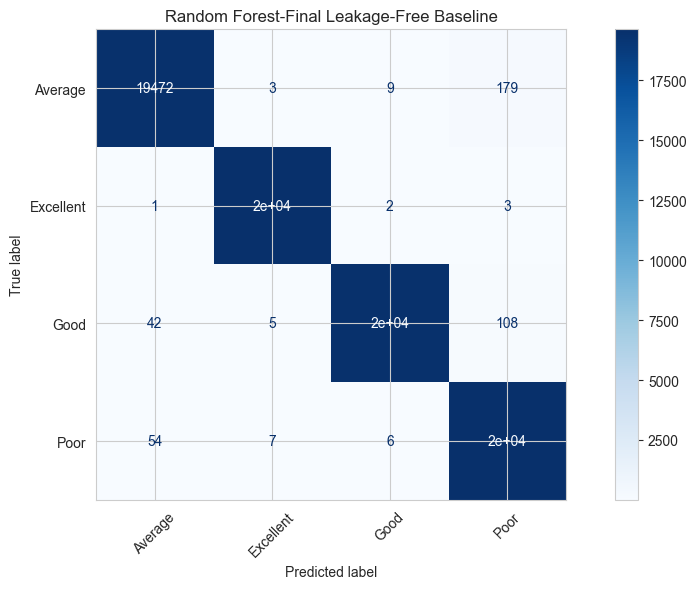

In [21]:
#Retraing Random Forest on the cleaned, leakage-free feature set 

rf_model=RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(x_train,y_train)
y_pred=rf_model.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:")
print(classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred,labels=rf_model.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=rf_model.classes_)
disp.plot(cmap="Blues",xticks_rotation=45)
plt.title("Random Forest-Final Leakage-Free Baseline")
plt.tight_layout()
plt.show()

In [22]:
final_leakage_columns=[
    "Batting_Average","Bowling_Average","Economy","Boundary_Percentage"
]
x=x.drop(columns=[col for col in final_leakage_columns if col in x.columns])
print("Final feature count:",x.shape[1])
print(x.columns.tolist())
correlations=x.select_dtypes(include=[np.number]).corrwith(df.loc[x.index,"Performance_Score"])
correlations=correlations.abs().sort_values(ascending=False)
print("\nTop correlations (should all be well under 0.5 now):")
print(correlations.head(10))

Final feature count: 25
['Stumpings', 'Injury_Status', 'Fatigue_Level', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall', 'Match_Type_MDM', 'Match_Type_ODI', 'Match_Type_ODM', 'Match_Type_T20', 'Match_Type_Test', 'Climate_Zone_Desert', 'Climate_Zone_Mediterranean', 'Climate_Zone_Oceanic', 'Climate_Zone_Semi-Arid', 'Climate_Zone_Subtropical', 'Climate_Zone_Temperate', 'Climate_Zone_Tropical', 'Climate_Zone_Tropical Monsoon', 'Climate_Zone_Warm Temperate', 'Team_freq', 'City_freq', 'Country_freq']

Top correlations (should all be well under 0.5 now):
Team_freq        0.304448
Stumpings        0.233640
Injury_Status    0.228255
Cloud_Cover      0.086701
Fatigue_Level    0.078580
Humidity         0.077944
Wind_Speed       0.047251
Country_freq     0.033381
Temperature      0.031853
City_freq        0.005604
dtype: float64


Top 15 most important features:
Batting_Average        0.163554
Boundary_Percentage    0.150903
Bowling_Average        0.133403
Economy                0.133011
Fatigue_Level          0.120870
Team_freq              0.094662
Stumpings              0.041897
Injury_Status          0.028804
City_freq              0.024608
Country_freq           0.018905
Cloud_Cover            0.014235
Humidity               0.014016
Temperature            0.013293
Wind_Speed             0.011100
Match_Type_T20         0.005154
dtype: float64


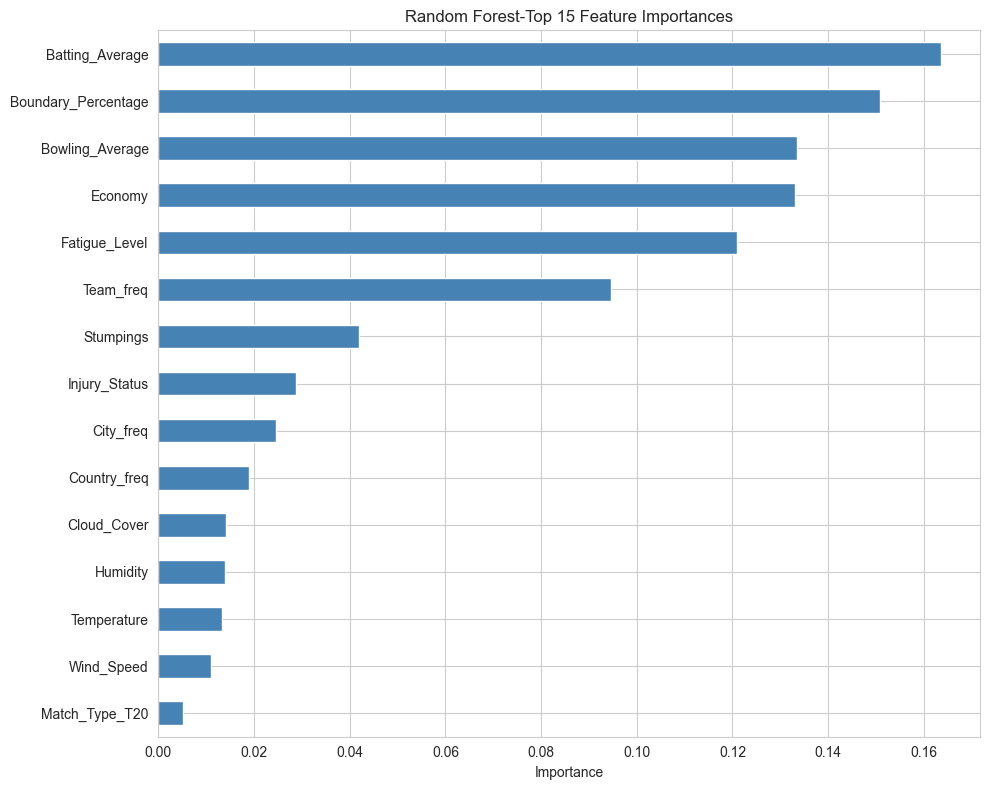

In [23]:
#feature importance-Random Forest

importances=pd.Series(
    rf_model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)
print("Top 15 most important features:")
print(importances.head(15))
plt.figure(figsize=(10,8))
importances.head(15).sort_values().plot(kind="barh",color="steelblue")
plt.title("Random Forest-Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [24]:
#Train XGBoost on the same cleaned ,leakage free feature set 

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_train_encoded=le.fit_transform(y_train)
y_test_encoded=le.transform(y_test)
print("Label mapping:",dict(zip(le.classes_,le.transform(le.classes_))))
xgb_model=XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
    n_jobs=-1
)
xgb_model.fit(x_train,y_train_encoded)
y_pred_xgb_encoded=xgb_model.predict(x_test)
y_pred_xgb=le.inverse_transform(y_pred_xgb_encoded)
print("\nXGBoost Accuracy:",accuracy_score(y_test,y_pred_xgb))
print("\nXGBoost Classification Report:")
print(classification_report(y_test,y_pred_xgb))

Label mapping: {'Average': np.int64(0), 'Excellent': np.int64(1), 'Good': np.int64(2), 'Poor': np.int64(3)}

XGBoost Accuracy: 0.9440383417449562

XGBoost Classification Report:
              precision    recall  f1-score   support

     Average       0.95      0.90      0.92     19663
   Excellent       0.99      1.00      0.99     19630
        Good       0.97      0.92      0.95     19696
        Poor       0.87      0.95      0.91     19672

    accuracy                           0.94     78661
   macro avg       0.95      0.94      0.94     78661
weighted avg       0.95      0.94      0.94     78661



In [25]:
#Train CatBoost 

cat_model=CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False
)
cat_model.fit(x_train,y_train)
y_pred_cat=cat_model.predict(x_test)
print("CatBoost Accuracy:",accuracy_score(y_test,y_pred_cat))
print("\nCatBoost Classification Report:")
print(classification_report(y_test,y_pred_cat))

CatBoost Accuracy: 0.8253391134107118

CatBoost Classification Report:
              precision    recall  f1-score   support

     Average       0.83      0.72      0.77     19663
   Excellent       0.89      0.98      0.93     19630
        Good       0.86      0.79      0.83     19696
        Poor       0.72      0.81      0.77     19672

    accuracy                           0.83     78661
   macro avg       0.83      0.83      0.82     78661
weighted avg       0.83      0.83      0.82     78661



          Model1  Accuracy  F1(weighted)
0  Random Forest  0.994673      0.994678
1        XGBoost  0.944038      0.944235
2       CatBoost  0.825339      0.824074


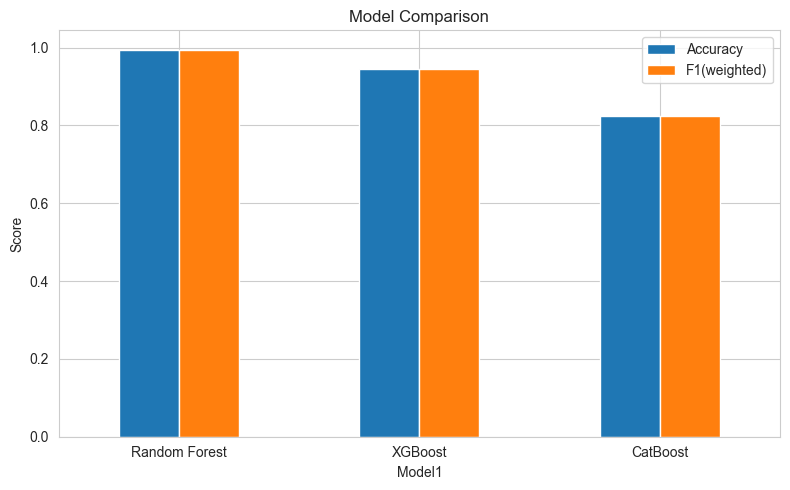

In [26]:
#comparison of all three models

comparison=pd.DataFrame({
    "Model1":["Random Forest", "XGBoost","CatBoost"],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred_xgb),
        accuracy_score(y_test,y_pred_cat),
    ],
    "F1(weighted)":[
        f1_score(y_test,y_pred,average="weighted"),
        f1_score(y_test,y_pred_xgb,average="weighted"),
        f1_score(y_test,y_pred_cat,average="weighted"),
    ]
})
print(comparison)
comparison.set_index("Model1")[["Accuracy","F1(weighted)"]].plot(kind="bar",figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
    

In [27]:
#SHAP values via-XGBoost

import xgboost as xgb
x_test_sample=x_test.sample(n=2000,random_state=RANDOM_STATE)
dtest=xgb.DMatrix(x_test_sample,feature_names=list(x_test_sample.columns))
contribs=xgb_model.get_booster().predict(dtest,pred_contribs=True)
print("Contributions array shape:",contribs.shape)

Contributions array shape: (2000, 4, 30)


In [28]:
#Extract SHAP values for the excellent 

excellent_class_index=list(le.classes_).index("Excellent")
shap_values_excellent=contribs[:,excellent_class_index,:-1]
print("Shape for plotting:",shap_values_excellent.shape)
print("Should match x_test_sample shape:",x_test_sample.shape)

Shape for plotting: (2000, 29)
Should match x_test_sample shape: (2000, 29)


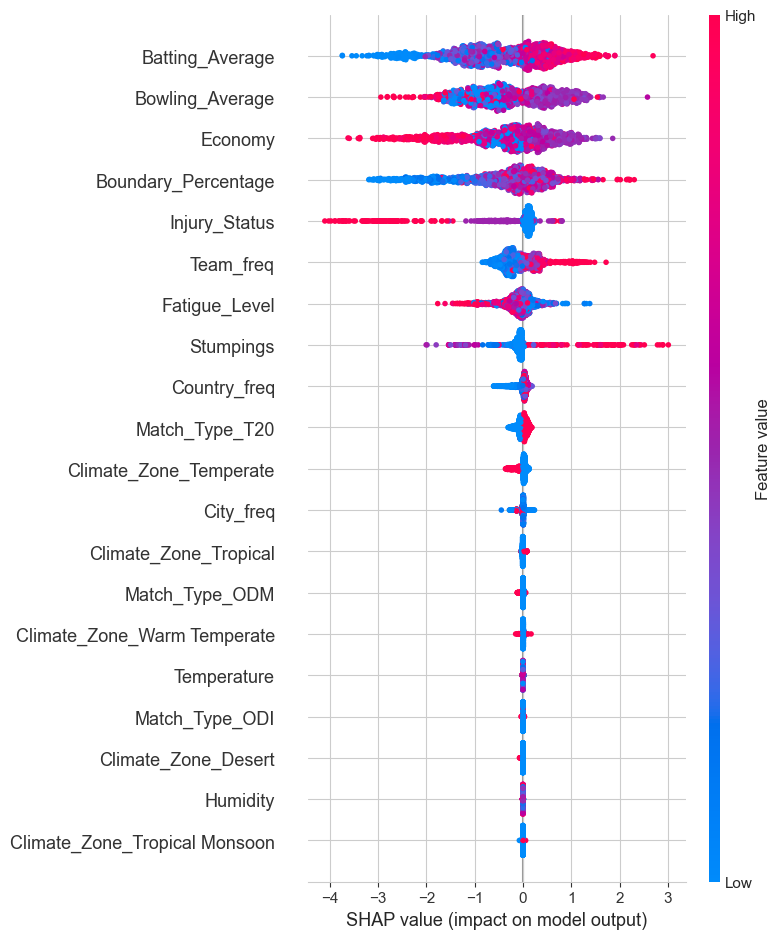

In [29]:
#SHAP summary plot

shap.summary_plot(shap_values_excellent,x_test_sample,show=True)

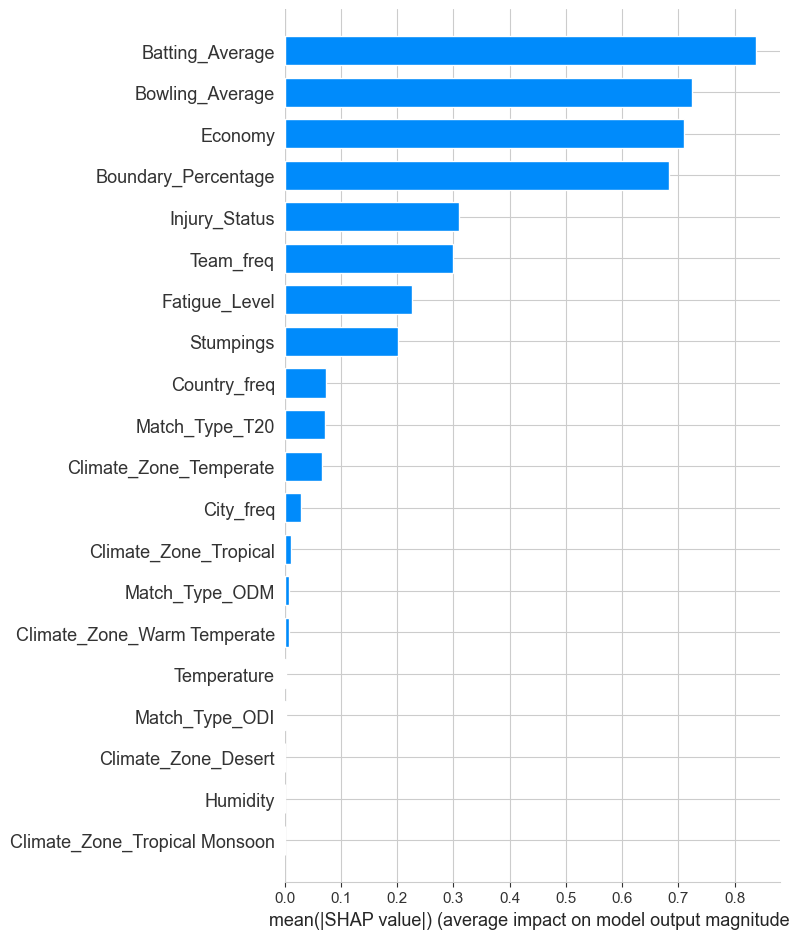

In [30]:
#SHAP bar plot  simplifying average importance 

shap.summary_plot(shap_values_excellent,x_test_sample,plot_type="bar",show=True)

In [31]:
print("All column names in df:")
print(df.columns.tolist())
role_like_cols=[c for c in df.columns if any(
    keyword in c.lower() for keyword in["role","position","type","category"]
)]
print("\nColumns that might represent role/position:")
print(role_like_cols)

All column names in df:
['Match_ID', 'Date', 'Team', 'Player', 'Matches', 'Innings', 'Runs', 'Balls', 'Fours', 'Sixes', 'Outs', 'Not_Outs', 'Batting_Average', 'Strike_Rate', 'Boundary_Percentage', 'Bowling_Matches', 'Balls_Bowled', 'Runs_Conceded', 'Wickets', 'Bowling_Average', 'Economy', 'Fielding_Matches', 'Catches', 'Run_Ounts', 'Stumpings', 'Fitness_Score', 'Injury_Status', 'Fatigue_Level', 'Match_Readiness', 'Match_Type', 'City', 'Country', 'Climate_Zone', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall', 'Runs_scaled', 'Strike_Rate_scaled', 'Wickets_scaled', 'Catches_scaled', 'Fitness_Score_scaled', 'Match_Readiness_scaled', 'Performance_Score', 'Performance_Category']

Columns that might represent role/position:
['Match_Type', 'Performance_Category']


In [32]:
injury_map={"No":0,"Minor":1,"Major":2}
temp_injury_numeric=df["Injury_Status"].map(injury_map)
check_df=df[["Fatigue_Level","Fitness_Score","Match_Readiness"]].copy()
check_df["Injury_Status"]=temp_injury_numeric
print(check_df.corr())

                 Fatigue_Level  Fitness_Score  Match_Readiness  Injury_Status
Fatigue_Level         1.000000       0.015452        -0.356454       0.010745
Fitness_Score         0.015452       1.000000         0.681798      -0.085409
Match_Readiness      -0.356454       0.681798         1.000000      -0.690485
Injury_Status         0.010745      -0.085409        -0.690485       1.000000


In [33]:
#Derive player roles

player_totals=df.groupby("Player").agg(
    total_balls_faced=("Balls","sum"),
    total_balls_bowled=("Balls_Bowled","sum"),
    total_stumpings=("Stumpings","sum")
).reset_index()

#define thresholds

BATTING_THRESHOLD=500
BOWLING_THRESHOLD=500
KEEPER_STUMPING_THRESHOLD=1
def assign_role(row):
    is_keeper=row["total_stumpings"]>=KEEPER_STUMPING_THRESHOLD
    is_batter=row["total_balls_faced"]>=BATTING_THRESHOLD
    is_bowler=row["total_balls_bowled"]>=BOWLING_THRESHOLD
    if is_keeper:
        return "Wicketkeeper"
    elif is_batter and is_bowler:
        return "All-rounder"
    elif is_bowler:
        return "Bowler"
    elif is_batter:
        return "Batter"
    else:
        return "Unclassified"
player_totals["Role"]=player_totals.apply(assign_role,axis=1)
print("Role distribution across all players:")
print(player_totals["Role"].value_counts())
print("\nSample of assigned roles:")
print(player_totals.head(10))

Role distribution across all players:
Role
All-rounder     3765
Unclassified    3175
Batter          1128
Bowler           939
Wicketkeeper     782
Name: count, dtype: int64

Sample of assigned roles:
           Player  total_balls_faced  total_balls_bowled  total_stumpings          Role
0          A Adey               34.0                36.0              0.0  Unclassified
1      A Ahmadhel              135.0                60.0              0.0  Unclassified
2     A Alexander              665.0              2052.0              0.0   All-rounder
3         A Amado               56.0                36.0              0.0  Unclassified
4      A Amburose               18.0                 0.0              0.0  Unclassified
5  A Anandakumara               44.0                 0.0              0.0  Unclassified
6       A Andrews               30.0               310.0              0.0  Unclassified
7      A Anlezark              120.0              1015.0              0.0        Bowler
8  A Ar

In [37]:
#Merge Role back into the main dataframe
df=df.merge(player_totals[["Player","Role"]],on="Player",how="left")
df["Role"]=df["Role"].fillna("Unclassified")
print("Role merged successfully.Sample:")
print(df[["Player","Role"]].drop_duplicates().head(10))

Role merged successfully.Sample:
         Player          Role
0     DA Warner   All-rounder
1      SE Marsh        Batter
2    UT Khawaja   All-rounder
3     SPD Smith   All-rounder
4      AC Voges   All-rounder
5      MR Marsh   All-rounder
6     PM Nevill  Wicketkeeper
7      MA Starc   All-rounder
8     PM Siddle   All-rounder
9  JR Hazlewood   All-rounder


In [127]:
code_to_write="""import pandas as pd
def recommend_playing_xi(candidate_players_df,model,feature_columns,label_encoder=None):
    pool=candidate_players_df.copy()
    X_pool=pool[feature_columns]

    if label_encoder is not None:
        probs=model.predict_proba(X_pool)
        excellent_idx=list(label_encoder.classes_).index("Excellent")
        good_idx=list(label_encoder.classes_).index("Good")
        pool["Selection_Score"]=probs[:,excellent_idx]+probs[:,good_idx]
    else:
        category_score_map={"Excellent":4,"Good":3,"Average":2,"Poor":1}
        preds=model.predict(X_pool)
        pool["Selection_Score"]=pd.Series(preds).map(category_score_map).values
    pool=pool.sort_values("Selection_Score",ascending=False)
    selected_players=[]
    kp=pool[(pool["Role"]=="Wicketkeeper")&(~pool["Player"].isin(selected_players))]
    selected_players+=kp.head(1)["Player"].tolist()
    bw=pool[(pool["Role"]=="Bowler")&(~pool["Player"].isin(selected_players))]
    selected_players+=bw.head(4)["Player"].tolist()
    ar=pool[(pool["Role"]=="All-rounder")&(~pool["Player"].isin(selected_players))]
    selected_players+=ar.head(2)["Player"].tolist()
    slots_left=11-len(selected_players)
    bt=pool[(pool["Role"]=="Batter")&(~pool["Player"].isin(selected_players))]
    selected_players+=bt.head(slots_left)["Player"].tolist()

    if len(selected_players)<11:
        slots_left=11-len(selected_players)
        fallback=pool[~pool["Player"].isin(selected_players)]
        selected_players+=fallback.head(slots_left)["Player"].tolist()
    
    xi_df=pool[pool["Player"].isin(selected_players)].drop_duplicates(subset="Player")
    xi_df=xi_df.sort_values("Selection_Score",ascending=False).head(11)
   
    return xi_df[["Player","Role","Selection_Score"]].reset_index(drop=True)
    """

with open("xi_function.py","w",encoding="utf-8") as f:
    f.write(code_to_write)

print("File written.Contents:")
print(open("xi_function.py").read())

File written.Contents:
import pandas as pd
def recommend_playing_xi(candidate_players_df,model,feature_columns,label_encoder=None):
    pool=candidate_players_df.copy()
    X_pool=pool[feature_columns]

    if label_encoder is not None:
        probs=model.predict_proba(X_pool)
        excellent_idx=list(label_encoder.classes_).index("Excellent")
        good_idx=list(label_encoder.classes_).index("Good")
        pool["Selection_Score"]=probs[:,excellent_idx]+probs[:,good_idx]
    else:
        category_score_map={"Excellent":4,"Good":3,"Average":2,"Poor":1}
        preds=model.predict(X_pool)
        pool["Selection_Score"]=pd.Series(preds).map(category_score_map).values
    pool=pool.sort_values("Selection_Score",ascending=False)
    selected_players=[]
    kp=pool[(pool["Role"]=="Wicketkeeper")&(~pool["Player"].isin(selected_players))]
    selected_players+=kp.head(1)["Player"].tolist()
    bw=pool[(pool["Role"]=="Bowler")&(~pool["Player"].isin(selected_players))]
    selected_playe

In [128]:
model_ready=x.copy()
model_ready["Player"]=df.loc[x.index,"Player"].values
model_ready["Match_ID"]=df.loc[x.index,"Match_ID"].values
model_ready["Role"]=df.loc[x.index,"Role"].values
print("model_ready shape:",model_ready.shape)
print(model_ready[["Player","Match_ID","Role"]].head())

model_ready shape: (393302, 28)
       Player  Match_ID         Role
0   DA Warner   1000851  All-rounder
1    SE Marsh   1000851       Batter
2  UT Khawaja   1000851  All-rounder
3   SPD Smith   1000851  All-rounder
4    AC Voges   1000851  All-rounder


In [129]:
#Retrain XGBoost on the current 
print("Current x_train shape:",x_train.shape)
print("Current x_Train columns:",x_train.columns.tolist())
xgb_model=XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
    n_jobs=-1
)
xgb_model.fit(x_train,y_train_encoded)
y_pred_xgb_encoded=xgb_model.predict(x_test)
y_pred_xgb=le.inverse_transform(y_pred_xgb_encoded)
print("\nXGBoost Accuracy(retrained,25 feature):",accuracy_score(y_test,y_pred_xgb))

Current x_train shape: (314641, 25)
Current x_Train columns: ['Stumpings', 'Injury_Status', 'Fatigue_Level', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall', 'Match_Type_MDM', 'Match_Type_ODI', 'Match_Type_ODM', 'Match_Type_T20', 'Match_Type_Test', 'Climate_Zone_Desert', 'Climate_Zone_Mediterranean', 'Climate_Zone_Oceanic', 'Climate_Zone_Semi-Arid', 'Climate_Zone_Subtropical', 'Climate_Zone_Temperate', 'Climate_Zone_Tropical', 'Climate_Zone_Tropical Monsoon', 'Climate_Zone_Warm Temperate', 'Team_freq', 'City_freq', 'Country_freq']

XGBoost Accuracy(retrained,25 feature): 0.6702813338248942


In [130]:
print("Number of features xgb_model expects:",xgb_model.n_features_in_)
print("Feature names xgb_model was trained on:")
print(list(xgb_model.get_booster().feature_names))

Number of features xgb_model expects: 25
Feature names xgb_model was trained on:
['Stumpings', 'Injury_Status', 'Fatigue_Level', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall', 'Match_Type_MDM', 'Match_Type_ODI', 'Match_Type_ODM', 'Match_Type_T20', 'Match_Type_Test', 'Climate_Zone_Desert', 'Climate_Zone_Mediterranean', 'Climate_Zone_Oceanic', 'Climate_Zone_Semi-Arid', 'Climate_Zone_Subtropical', 'Climate_Zone_Temperate', 'Climate_Zone_Tropical', 'Climate_Zone_Tropical Monsoon', 'Climate_Zone_Warm Temperate', 'Team_freq', 'City_freq', 'Country_freq']


In [131]:
xgb_model=XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
    n_jobs=-1
)
xgb_model.fit(x_train,y_train_encoded)
print("Retrained.Feature count:",xgb_model.n_features_in_)
print("Feature names:",list(xgb_model.get_booster().feature_names))


Retrained.Feature count: 25
Feature names: ['Stumpings', 'Injury_Status', 'Fatigue_Level', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall', 'Match_Type_MDM', 'Match_Type_ODI', 'Match_Type_ODM', 'Match_Type_T20', 'Match_Type_Test', 'Climate_Zone_Desert', 'Climate_Zone_Mediterranean', 'Climate_Zone_Oceanic', 'Climate_Zone_Semi-Arid', 'Climate_Zone_Subtropical', 'Climate_Zone_Temperate', 'Climate_Zone_Tropical', 'Climate_Zone_Tropical Monsoon', 'Climate_Zone_Warm Temperate', 'Team_freq', 'City_freq', 'Country_freq']


In [132]:
#Rebuild train/test split from the current x
print("Current x shape (should be 25 columns):",x.shape)
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)
print("x_train shape:",x_train.shape)
print("x_train columns:",x_train.columns.tolist())

Current x shape (should be 25 columns): (393302, 25)
x_train shape: (314641, 25)
x_train columns: ['Stumpings', 'Injury_Status', 'Fatigue_Level', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall', 'Match_Type_MDM', 'Match_Type_ODI', 'Match_Type_ODM', 'Match_Type_T20', 'Match_Type_Test', 'Climate_Zone_Desert', 'Climate_Zone_Mediterranean', 'Climate_Zone_Oceanic', 'Climate_Zone_Semi-Arid', 'Climate_Zone_Subtropical', 'Climate_Zone_Temperate', 'Climate_Zone_Tropical', 'Climate_Zone_Tropical Monsoon', 'Climate_Zone_Warm Temperate', 'Team_freq', 'City_freq', 'Country_freq']


In [133]:
y_train_encoded=le.fit_transform(y_train)
y_test_encoded=le.transform(y_test)
xgb_model=XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
    n_jobs=-1
)
xgb_model.fit(x_train,y_train_encoded)
print("Retrained.Feature count:",xgb_model.n_features_in_)
print("Feature names:",list(xgb_model.get_booster().feature_names))

Retrained.Feature count: 25
Feature names: ['Stumpings', 'Injury_Status', 'Fatigue_Level', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall', 'Match_Type_MDM', 'Match_Type_ODI', 'Match_Type_ODM', 'Match_Type_T20', 'Match_Type_Test', 'Climate_Zone_Desert', 'Climate_Zone_Mediterranean', 'Climate_Zone_Oceanic', 'Climate_Zone_Semi-Arid', 'Climate_Zone_Subtropical', 'Climate_Zone_Temperate', 'Climate_Zone_Tropical', 'Climate_Zone_Tropical Monsoon', 'Climate_Zone_Warm Temperate', 'Team_freq', 'City_freq', 'Country_freq']


In [134]:
if "recommend_playing_xi" in dir():
    del recommend_playing_xi

from xi_function import recommend_playing_xi
import inspect
print(inspect.getsource(recommend_playing_xi))


def recommend_playing_xi(candidate_players_df,model,feature_columns,label_encoder=None):
    pool=candidate_players_df.copy()
    X_pool=pool[feature_columns]

    if label_encoder is not None:
        probs=model.predict_proba(X_pool)
        excellent_idx=list(label_encoder.classes_).index("Excellent")
        good_idx=list(label_encoder.classes_).index("Good")
        pool["Selection_Score"]=probs[:,excellent_idx]+probs[:,good_idx]
    else:
        category_score_map={"Excellent":4,"Good":3,"Average":2,"Poor":1}
        preds=model.predict(X_pool)
        pool["Selection_Score"]=pd.Series(preds).map(category_score_map).values
    pool=pool.sort_values("Selection_Score",ascending=False)
    selected_players=[]
    kp=pool[(pool["Role"]=="Wicketkeeper")&(~pool["Player"].isin(selected_players))]
    selected_players+=kp.head(1)["Player"].tolist()
    bw=pool[(pool["Role"]=="Bowler")&(~pool["Player"].isin(selected_players))]
    selected_players+=bw.head(4)["Player"].tolist()
    ar=po

In [135]:
recommended_xi=recommend_playing_xi(
    candidates,
    model=xgb_model,
    feature_columns=feature_columns,
    label_encoder=le
)
print(f"Recommended XI for match {sample_match_id}:")
print(recommended_xi)

Recommended XI for match 1000851:
          Player          Role  Selection_Score
0      Q de Kock  Wicketkeeper         0.999861
1     UT Khawaja   All-rounder         0.938497
2       MA Starc   All-rounder         0.894754
3      DA Warner   All-rounder         0.894754
4       MR Marsh   All-rounder         0.883529
5   JR Hazlewood   All-rounder         0.875424
6     KA Maharaj   All-rounder         0.872861
7      JP Duminy   All-rounder         0.839118
8       K Rabada   All-rounder         0.829624
9       T Bavuma   All-rounder         0.829624
10      SE Marsh        Batter         0.444241


In [137]:
model_ready["Team"]=df.loc[x.index,"Team"].values
print("Team added.sample:")
print(model_ready[["Player","Team","Match_ID"]].head())

Team added.sample:
       Player       Team  Match_ID
0   DA Warner  Australia   1000851
1    SE Marsh  Australia   1000851
2  UT Khawaja  Australia   1000851
3   SPD Smith  Australia   1000851
4    AC Voges  Australia   1000851


In [139]:
#Match between two teams 
def find_matches_between(team_a,team_b,match_df):
    mask=(
        ((matches_df["India"]==team_a)&(matches_df["Ireland"]==team_b))
        ((matches_df["India"]==team_b)&(matches_df["Ireland"]==team_a))
    )
    return matches_df[mask][["Match_ID","Date","Team1","Team2","Venue"]]
print(df.columns.tolist())

['Match_ID', 'Date', 'Team', 'Player', 'Matches', 'Innings', 'Runs', 'Balls', 'Fours', 'Sixes', 'Outs', 'Not_Outs', 'Batting_Average', 'Strike_Rate', 'Boundary_Percentage', 'Bowling_Matches', 'Balls_Bowled', 'Runs_Conceded', 'Wickets', 'Bowling_Average', 'Economy', 'Fielding_Matches', 'Catches', 'Run_Ounts', 'Stumpings', 'Fitness_Score', 'Injury_Status', 'Fatigue_Level', 'Match_Readiness', 'Match_Type', 'City', 'Country', 'Climate_Zone', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Rainfall', 'Runs_scaled', 'Strike_Rate_scaled', 'Wickets_scaled', 'Catches_scaled', 'Fitness_Score_scaled', 'Match_Readiness_scaled', 'Performance_Score', 'Performance_Category', 'Role_x', 'Role_y', 'Role']


In [143]:
#Rebuild role column from player_totals
df=df.merge(player_totals[["Player","Role"]],on="Player",how="left")
df["Role"]=df["Role"].fillna("Unclassified")
print("Role column added.Sample:")
print(df[["Player","Role"]].drop_duplicates().head())
print("\nRole distribution:")
print(df["Role"].value_counts())

Role column added.Sample:
       Player         Role
0   DA Warner  All-rounder
1    SE Marsh       Batter
2  UT Khawaja  All-rounder
3   SPD Smith  All-rounder
4    AC Voges  All-rounder

Role distribution:
Role
All-rounder     290579
Wicketkeeper     60333
Batter           25132
Unclassified      8775
Bowler            8483
Name: count, dtype: int64


In [145]:
model_ready=x.copy()
model_ready["Player"]=df.loc[x.index,"Player"].values
model_ready["Match_ID"]=df.loc[x.index,"Match_ID"].values
model_ready["Role"]=df.loc[x.index,"Role"].values
model_ready["Team"]=df.loc[x.index,"Team"].values
print("model_ready rebuilt.Sample:")
print(model_ready[["Player","Team","Role","Match_ID"]].head())

model_ready rebuilt.Sample:
       Player       Team         Role  Match_ID
0   DA Warner  Australia  All-rounder   1000851
1    SE Marsh  Australia       Batter   1000851
2  UT Khawaja  Australia  All-rounder   1000851
3   SPD Smith  Australia  All-rounder   1000851
4    AC Voges  Australia  All-rounder   1000851


In [147]:
match_teams=df.groupby("Match_ID")["Team"].unique().reset_index()
match_teams.columns=["Match_ID","Teams_Involved"]
print("match_teams rebuilt.Sample:")
print(match_teams.head())

match_teams rebuilt.Sample:
   Match_ID            Teams_Involved
0     63963          [England, India]
1     64012      [Australia, England]
2     64013      [England, Australia]
3     64022  [South Africa, Pakistan]
4     64023  [South Africa, Pakistan]


In [152]:
code_to_write='''import pandas as pd
def find_matches_between(team_a,team_b,match_team_df,matches_meta_df):
    def has_both_teams(teams_list):
        return team_a in teams_list and team_b in teams_list
    mask=match_teams_df["Teams_Involved"].apply(has_both_teams)
    matching_ids=match_teams_df[mask]["Match_ID"]
    result=matches_meta_df[matches_meta_df["Match_Id"].isin(matching_ids)]
    return result[["Match_ID","Date","Venue"]].drop_duplicates()
def recommend_xi_for_fixture(team_a,team_b,model_ready_df,match_teams_df,
                             matches_meta_df,model,feature_columns,label_encoder,recommend_fn):
    fixtures=find_matches_between(team_a,team_b,match_teams_df,matches_meta_df)
    if len(fixtures)==0:
        print(f"No matches found between{team_a} and {team_b} in the dataset.")
        return None,None
    fixtures_sorted=fixtures.sort_values("Date",ascending=False)
    chosen_match_id=fixtures_sorted.iloc[0]["Match_ID"]
    chosen_date=fixtures_sorted.iloc[0]["Date"]
    chosen_venue=fixture_sorted.iloc[0]["Venue"]
    print(f"Using match {chosen_match_id} ({chosen_date}) at {chosen_venue}")
    print(f"({len(fixtures)} total matches found between these teams: using most recent)\\n")
    match_players=model_ready_df[model_ready_df["Match_ID"]==chosen_match_id]
    team_a_players=match_players[match_players["Team"]==team_a]
    team_b_players=match_players[match_players["Team"]==team_b]
    print(f"{team_a}:{len(team_a_players)}players found")
    print(f"{team_b}:{len(team_b_players)}players found\\n")
    xi_a=recommend_fn(team_a_players,model,feature_columns,label_encoder)if len(team_a_players)>0 else None
    xi_b=recommend_fn(team_b_players,model,feature_columns,label_encoder)if len(team_b_players)>0 else None
    return xi_a,xi_b
'''
with open("fixture_functions.py","w",encoding="utf-8") as f:
    f.write(code_to_write)
print("File written successfully.")

File written successfully.


In [153]:
if "find_matches_between" in dir():
    del find_matches_between
if "recommend_xi_for_fixture" in dir():
    del recommend_xi_for_fixture
from fixture_functions import find_matches_between,recommend_xi_for_fixture
print("Function loaded successfully.")

Function loaded successfully.


In [154]:
xi_india,xi_ireland=recommend_xi_for_fixture(
    "India","Ireland",
    model_ready_df=model_ready,
    match_teams_df=match_teams,
    matches_meta_df=df,
    model=xgb_model,
    feature_columns=feature_columns,
    label_encoder=le,
    recommend_fn=recommend_playing_xi
)
print("=== Recommended India XI ===")
print(xi_india)
print("\n=== Recommended Ireland XI===")
print(xi_ireland)

NameError: name 'match_teams_df' is not defined